In [69]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [70]:
import numpy as np
r = np.full((20, 1000),fill_value=np.nan)

In [71]:
import pandas as pd
df = pd.read_csv('ratings_long.csv')

In [72]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [73]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

In [74]:
import numpy as np
known_indices = np.argwhere(~np.isnan(r))
U = np.random.rand(20,4)
V = np.random.rand(4,1000)

In [76]:
from sklearn.model_selection import train_test_split

U = np.random.rand(20,4)
V = np.random.rand(4,1000)
epoch_loss_record=[]
train_indices, test_indices = train_test_split(known_indices,test_size=0.3, random_state=42, shuffle=True )
for e in range(epoch):
    squared_loss = 0
    for i, j in train_indices:
        real_val = r[i, j]
        pred_val = np.dot(U[i, :], V[:, j])
        loss = real_val - pred_val
        squared_loss += loss ** 2

        for k in range(4):
            old_u = U[i, k]
            u_regression = lamb if U[i, k] > 0 else -lamb
            U[i, k] -= learning_rate * (-2 * loss * V[k, j] + u_regression)

            v_regression = lamb if V[k, j] > 0 else -lamb
            V[k, j] -= learning_rate * (-2 * loss * old_u + v_regression)

    avg_loss = squared_loss / len(train_indices)
    epoch_loss_record.append(avg_loss)

In [77]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

y_true = []
y_pred = []

for i, j in test_indices:
    y_true.append(r[i, j])
    y_pred.append(np.dot(U[i, :], V[:, j]))
    
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)


print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")


Test MSE: 3.8379
Test RMSE: 1.9591


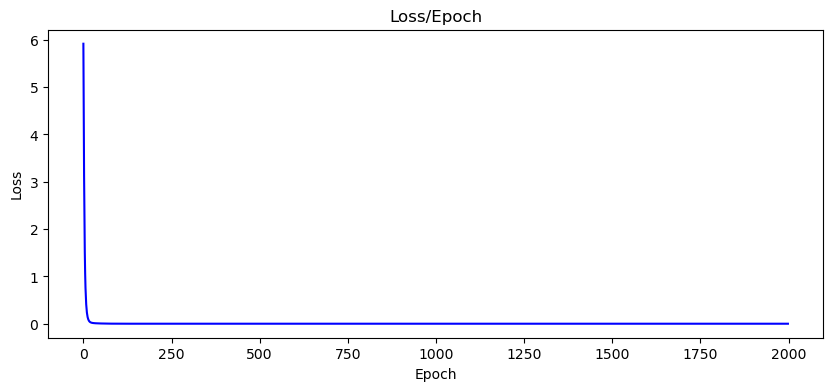

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(epoch_loss_record, color ="Blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss/Epoch")
plt.show()